In [3]:
# Import lib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import duckdb
import missingno as msno

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Load dataset

listings = pd.read_csv("/content/drive/MyDrive/Airbnb_london_raw_data/listings.csv")
calendar = pd.read_csv("/content/drive/MyDrive/Airbnb_london_raw_data/calendar.csv")
reviews = pd.read_csv("/content/drive/MyDrive/Airbnb_london_raw_data/reviews.csv")

print("Listings:", listings.shape)
print("Calendar:", calendar.shape)
print("Reviews:", reviews.shape)

Listings: (92638, 90)
Calendar: (33871636, 5)
Reviews: (2241353, 6)
Neighbourhoods: (33, 2)


In [5]:
# View first rows

listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551,https://www.airbnb.com/rooms/11551,20260619061251,2026-06-25,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039,https://www.airbnb.com/users/show/43039,1.462507e+18,https://www.airbnb.com/users/profile/146250747...,Adriano,NaN,16.0,8.0,15.0,5.0,"London, United Kingdom","Hello, I'm a friendly Italian man with a posit...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,1.0,NaN,NaN,t,t,NaN,Lambeth,NaN,51.46095,-0.11758,Entire rental unit,Entire home/apt,5,1.0,1 bath,1.0,3.0,"[""Carbon monoxide alarm"", ""Portable air condit...",$234.50,2026-07-01,2026-07-03,469.0,234.50,"{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",1.0,1125.0,1.0,5.0,1.0,1125.0,2.0,143.5,NaN,t,9,25,55,330,2026-06-25,196,6,1,155,3,55,12898.0,2010-03-21,2026-06-05,4.55,4.60,4.57,4.77,4.84,4.54,4.49,NaN,NaN,1,1,0,0,0.99
1,13913,https://www.airbnb.com/rooms/13913,20260619061251,2026-06-25,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730,https://www.airbnb.com/users/show/54730,1.462508e+18,https://www.airbnb.com/users/profile/146250779...,Alina,NaN,16.0,7.0,15.0,5.0,"London, United Kingdom",I am a Multi-Media Visual Artist and Creative ...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/54730/profile...,NaN,2.0,NaN,NaN,t,t,NaN,Islington,NaN,51.56861,-0.11270,Private room in rental unit,Private room,1,1.0,1 shared bath,NaN,1.0,"[""Babysitter recommendations"", ""Coffee maker: ...",$127.00,2026-06-26,2026-06-27,127.0,127.00,"{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",1.0,29.0,1.0,1.0,29.0,29.0,1.0,29.0,NaN,t,17,46,76,351,2026-06-25,57,3,0,176,6,28,3556.0,2010-08-18,2026-03-31,4.86,4.80,4.80,4.82,4.88,4.79,4.79,NaN,NaN,2,1,1,0,0.30
2,15400,https://www.airbnb.com/rooms/15400,20260619061251,2026-06-26,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302,https://www.airbnb.com/users/show/60302,1.462508e+18,https://www.airbnb.com/users/profile/146250797...,Philippa,NaN,16.0,6.0,15.0,5.0,"Royal Borough of Kensington and Chelsea, Unite...","English, grandmother, I have t

In [6]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11551,30672,2010-03-21,93896,Shar-Lyn,"The flat was bright, comfortable and clean and..."
1,11551,32236,2010-03-29,97890,Zane,We stayed with Adriano and Valerio for a week ...
2,11551,41044,2010-05-09,104133,Chase,Adriano was a fantastic host. We felt very at ...
3,11551,48926,2010-06-01,122714,John & Sylvia,We had a most wonderful stay with Adriano and ...
4,11551,58352,2010-06-28,111543,Monique,I'm not sure which of us misunderstood the s...


In [7]:
calendar.head()

,listing_id,date,available,minimum_nights,maximum_nights
0,11551,2026-06-25,f,1,1125
1,11551,2026-06-26,f,1,1125
2,11551,2026-06-27,f,1,1125
3,11551,2026-06-28,f,1,1125
4,11551,2026-06-29,f,1,1125


In [8]:
# View columns

listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [12]:
calendar.columns

Index(['listing_id', 'date', 'available', 'minimum_nights', 'maximum_nights'], dtype='object')

In [13]:
reviews.columns

Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'], dtype='object')

In [15]:
# View data types

listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            92638 non-null  int64  
 1   listing_url                                   92638 non-null  object 
 2   scrape_id                                     92638 non-null  int64  
 3   last_scraped                                  92638 non-null  object 
 4   source                                        92638 non-null  object 
 5   name                                          92638 non-null  object 
 6   description                                   90549 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   92633 non-null  object 
 9   host_id                                       92638 non-null 

In [16]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33871636 entries, 0 to 33871635
Data columns (total 5 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   listing_id      int64 
 1   date            object
 2   available       object
 3   minimum_nights  int64 
 4   maximum_nights  int64 
dtypes: int64(3), object(2)
memory usage: 1.3+ GB


In [17]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2241353 entries, 0 to 2241352
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   listing_id     int64 
 1   id             int64 
 2   date           object
 3   reviewer_id    int64 
 4   reviewer_name  object
 5   comments       object
dtypes: int64(3), object(3)
memory usage: 102.6+ MB


In [18]:
# Descriptive statistics
listings.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_response_time,host_response_rate,host_acceptance_rate,host_thumbnail_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,neighbourhood,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price_quote_total_price,price_quote_price_per_night,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,9.263800e+04,9.263800e+04,0.0,9.263800e+04,9.256200e+04,0.0,92562.000000,92562.000000,92561.000000,92561.000000,0.0,0.0,0.0,0.0,0.0,92562.000000,0.0,0.0,0.0,0.0,92638.000000,92638.000000,92638.000000,57762.000000,68655.000000,60163.000000,62240.000000,62240.000000,92633.000000,9.263300e+04,92633.000000,92633.000000,9.263300e+04,9.263300e+04,92638.000000,9.263800e+04,0.0,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,6.224000e+04,70711.000000,70697.000000,70702.000000,70673.000000,70692.000000,70672.000000,70672.000000,0.0,0.0,92638.000000,92638.000000,92638.000000,92638.000000,70711.000000
mean,8.174866e+17,2.026062e+13,NaN,1.361402e+16,1.475942e+18,NaN,7.670037,5.454539,5.556023,5.400352,NaN,NaN,NaN,NaN,NaN,53.821774,NaN,NaN,NaN,NaN,51.509225,-0.128647,3.387141,1.370174,1.767912,2.020993,1046.141884,271.469220,4.557631,2.148486e+05,4.557631,7.766563,7.572937e+04,2.148486e+05,6.017677,2.144453e+05,NaN,8.636737,21.756633,36.255165,152.664447,24.148654,6.113971,0.545921,82.941687,5.402329,47.600542,1.432758e+04,4.692911,4.732866,4.660909,4.797939,4.818871,4.741178,4.628688,NaN,NaN,16.402599,13.988547,2.248343,0.028843,0.987125
std,6.546986e+17,2.925797e+00,NaN,1.508990e+17,3.845402e+16,NaN,4.120067,3.554372,3.979819,3.594906,NaN,NaN,NaN,NaN,NaN,444.149665,NaN,NaN,NaN,NaN,0.049589,0.101645,2.120560,0.735683,1.042125,1.451603,5266.822582,2190.599006,20.895917,2.123659e+07,20.895917,28.589762,1.234193e+07,2.123659e+07,22.233763,2.119751e+07,NaN,10.180460,21.698970,33.559887,141.132463,55.082865,12.614952,1.269532,74.129129,12.243478,76.113455,2.818465e+04,0.482131,0.465147,0.501149,0.413750,0.414242,0.394309,0.495310,NaN,NaN,49.874854,48.925545,9.551793,0.649517,1.317630
min,1.155100e+04,2.026062e+13,NaN,2.594000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,51.295937,-0.496760,1.000000,0.500000,0.000000,1.000000,10.000000,2.230000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.540656e+07,2.026062e+13,NaN,2.788031e+07,1.463035e+18,NaN,4.000000,2.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,51.483519,-0.190240,2.000000,1.000000,1.000000,1.000000,166.000000,100.000000,1.000000,9.900000e+01,1.000000,2.000000,9.000000e+01,9.900000e+01,1.000000,9.900000e+01,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,4.600000,4

In [19]:
listings.describe(include="object")

,listing_url,last_scraped,source,name,description,picture_url,host_url,host_profile_url,host_name,host_location,host_about,host_is_superhost,host_picture_url,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_raw,has_availability,calendar_last_scraped,first_review,last_review
count,92638,92638,92638,92638,90549,92633,92638,92554,92562,69928,49229,92562,92562,92562,92562,92638,92638,92638,92504,92638,62240,64771,64771,64771,91778,92638,70711,70711
unique,92638,9,2,89657,80476,90782,52125,52101,15841,1702,23518,2,49349,2,2,33,91,4,49,84649,11970,363,372,53655,2,9,4832,3792
top,https://www.airbnb.com/rooms/1710933572119600327,2026-06-29,city scrape,Home away from home,Enjoy a stylish experience at this centrally-l...,https://a0.muscache.com/pictures/9fb04d2d-e9f4...,https://www.airbnb.com/users/show/446820235,https://www.airbnb.com/users/profile/146372301...,Julie,"London, United Kingdom",We are your professional property manager that...,f,https://a0.muscache.com/im/Portrait/Avatars/v2...,t,t,Westminster,Entire rental unit,Entire home/apt,1 bath,[],$80.00,2026-06-29,2026-06-30,"{""quote"": {""taxes"": null, ""currency"": null, ""d...",t,2026-06-29,2026-04-26,2026-06-14
freq,1,23504,61587,29,356,22,501,501,630,50354,525,75003,518,87879,91162,10876,40129,61377,42502,192,396,4385,3732,141,91670,23504,243,1719


In [20]:
# Check missing values
missing = listings.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

,0
neighborhood_overview,92638
host_since,92638
host_neighbourhood,92638
host_total_listings_count,92638
neighbourhood,92638
host_verifications,92638
host_response_rate,92638
host_acceptance_rate,92638
host_thumbnail_url,92638
host_response_time,92638


In [21]:
missing_percent = listings.isnull().mean()*100
missing_percent = missing_percent.sort_values(ascending=False)
missing_percent.head(30)

,0
neighborhood_overview,100.000000
host_since,100.000000
host_response_time,100.000000
host_thumbnail_url,100.000000
host_acceptance_rate,100.000000
host_response_rate,100.000000
host_verifications,100.000000
neighbourhood,100.000000
host_total_listings_count,100.000000
host_neighbourhood,100.000000


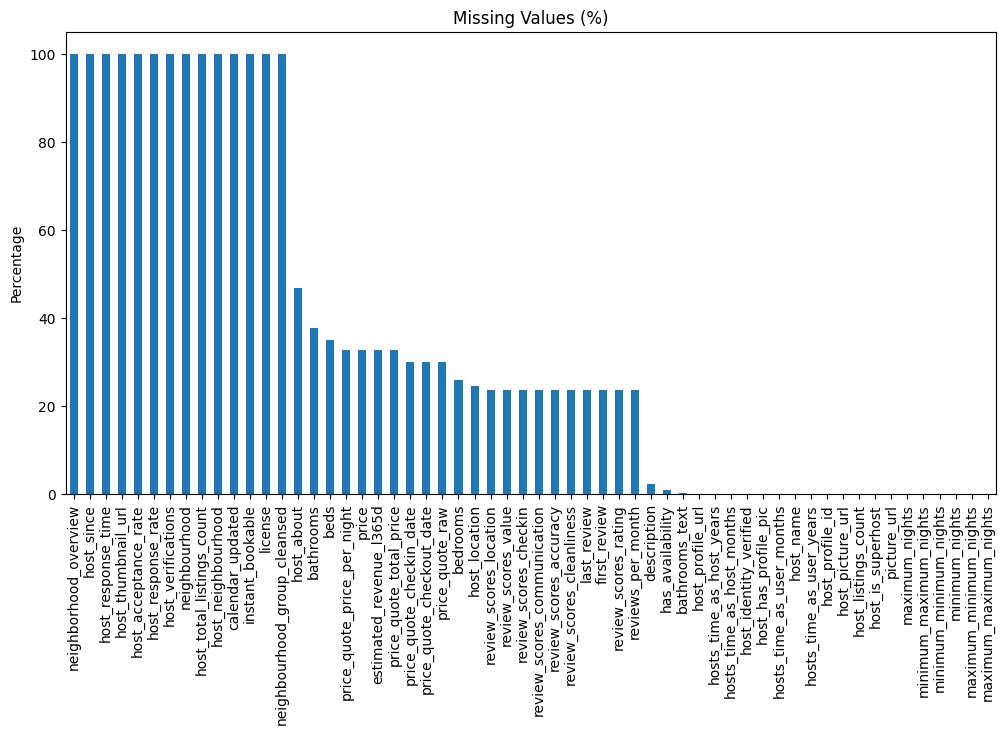

In [22]:
plt.figure(figsize=(12,6))
missing_percent[missing_percent>0].plot(kind='bar')
plt.title("Missing Values (%)")
plt.ylabel("Percentage")
plt.show()

In [24]:
# Check duplicate records

print("Listings duplicates:", listings.duplicated().sum())
print("Calendar duplicates:", calendar.duplicated().sum())
print("Reviews duplicates:", reviews.duplicated().sum())

Listings duplicates: 0
Calendar duplicates: 0
Reviews duplicates: 0


In [25]:
# Check unique values

for col in listings.columns:
  print(col, listings[col].nunique())

id 92638
listing_url 92638
scrape_id 1
last_scraped 9
source 2
name 89657
description 80476
neighborhood_overview 0
picture_url 90782
host_id 52125
host_url 52125
host_profile_id 52096
host_profile_url 52101
host_name 15841
host_since 0
hosts_time_as_user_years 18
hosts_time_as_user_months 12
hosts_time_as_host_years 16
hosts_time_as_host_months 12
host_location 1702
host_about 23518
host_response_time 0
host_response_rate 0
host_acceptance_rate 0
host_is_superhost 2
host_thumbnail_url 0
host_picture_url 49349
host_neighbourhood 0
host_listings_count 154
host_total_listings_count 0
host_verifications 0
host_has_profile_pic 2
host_identity_verified 2
neighbourhood 0
neighbourhood_cleansed 33
neighbourhood_group_cleansed 0
latitude 53890
longitude 62852
property_type 91
room_type 4
accommodates 16
bathrooms 27
bathrooms_text 49
bedrooms 21
beds 28
amenities 84649
price 11970
price_quote_checkin_date 363
price_quote_checkout_date 372
price_quote_total_price 9939
price_quote_price_per_nigh

In [26]:
# Check Primary Keys
listings["id"].is_unique

True

In [27]:
reviews["listing_id"].head()

,listing_id
0,11551
1,11551
2,11551
3,11551
4,11551


In [28]:
calendar["listing_id"].head()

,listing_id
0,11551
1,11551
2,11551
3,11551
4,11551


In [29]:
# Data quality summary

quality = pd.DataFrame({
    "Column": listings.columns,
    "Data Type": listings.dtypes.values,
    "Missing Values": listings.isnull().sum().values,
    "Missing %": (listings.isnull().mean()*100).values,
    "Unique Values": listings.nunique().values
})

quality

,Column,Data Type,Missing Values,Missing %,Unique Values
0,id,int64,0,0.000000,92638
1,listing_url,object,0,0.000000,92638
2,scrape_id,int64,0,0.000000,1
3,last_scraped,object,0,0.000000,9
4,source,object,0,0.000000,2
5,name,object,0,0.000000,89657
6,description,object,2089,2.255014,80476
7,neighborhood_overview,float64,92638,100.000000,0
8,picture_url,object,5,0.005397,90782
9,host_id,int64,0,0.000000,52125


In [30]:
quality.to_csv("listing_data_quality_report.csv", index=False)

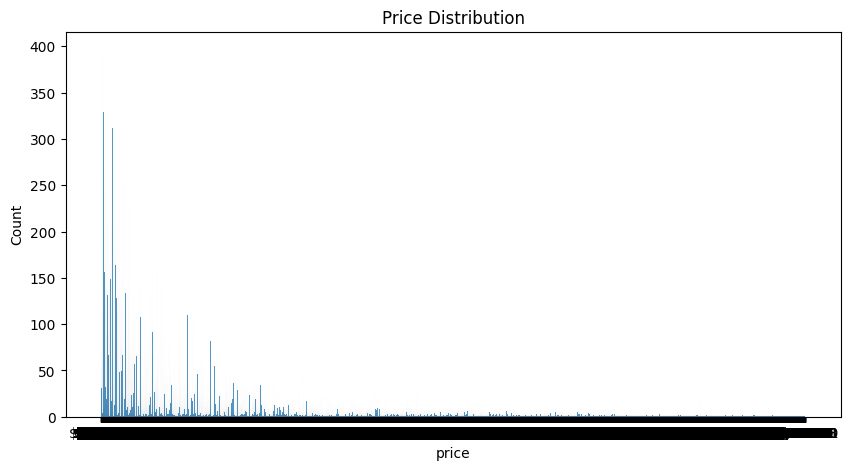

In [37]:
# Check Distribution of Prices

plt.figure(figsize=(10,5))
sns.histplot(listings["price"], bins=40)
plt.title("Price Distribution")
plt.show()

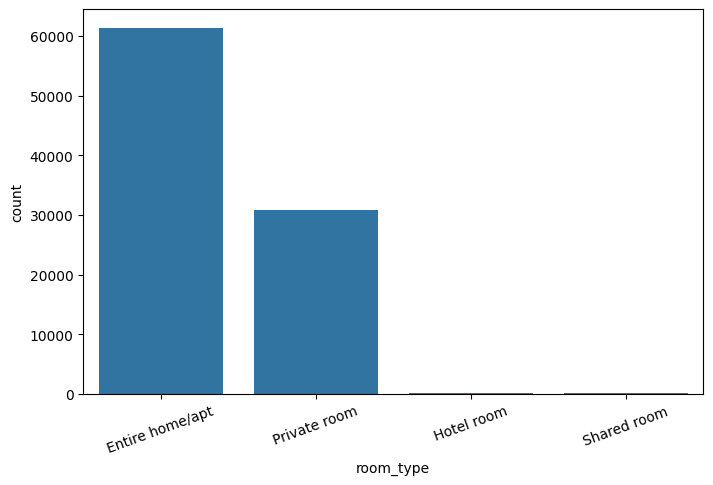

In [32]:
# Check Room Type Distribution

plt.figure(figsize=(8,5))
sns.countplot(data=listings, x="room_type")
plt.xticks(rotation=20)
plt.show()

In [34]:
# Property Types

listings["property_type"].value_counts().head(20)

,count
property_type,
Entire rental unit,40129
Private room in rental unit,12907
Private room in home,10846
Entire home,9153
Entire condo,7935
Private room in condo,3047
Entire serviced apartment,1862
Room in hotel,1253
Private room in townhouse,1097
